<a href="https://colab.research.google.com/github/GulsumSayin/satellite-based-water-change-detection/blob/main/water_body_segmentation_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Gerekli Kütüphanelerin İmport Edilmesi

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam

**Drive'a Bağlanma**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Veri Setinin Model Girişine Uygun Hale Getirilmesi

In [ ]:
image_dir = '/content/drive/MyDrive/Water Bodies Dataset/Images'
mask_dir = '/content/drive/MyDrive/Water Bodies Dataset/Masks'

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image

# Ortak dosya adlarını al (sadece hem görüntü hem maske olanlar)
image_names = set(os.listdir(image_dir))
mask_names = set(os.listdir(mask_dir))
common_files = sorted(list(image_names & mask_names))

# Güncellenmiş yollar
image_paths = [os.path.join(image_dir, fname) for fname in common_files]
mask_paths = [os.path.join(mask_dir, fname) for fname in common_files]

# PIL ile görüntü yükleme
def load_image(path, target_size=(256, 256)):
    img = Image.open(path).convert("RGB")
    img = img.resize(target_size)
    img = np.asarray(img, dtype=np.float32) / 255.0
    return img

# PIL ile maske yükleme
def load_mask(path, target_size=(256, 256)):
    mask = Image.open(path).convert("L")
    mask = mask.resize(target_size)
    mask = np.asarray(mask, dtype=np.uint8)
    mask = (mask > 127).astype(np.float32)
    return np.expand_dims(mask, axis=-1)

# Sadece eşleşen dosyalar yüklenir
X = np.array([load_image(p) for p in image_paths])
Y = np.array([load_mask(p) for p in mask_paths])

print("Görüntü sayısı:", len(X))
print("Maske sayısı:", len(Y))

# Eğitim ve doğrulama bölme
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

Görüntü sayısı: 2841
Maske sayısı: 2841


**Veri Setinden Örneklerin Görselleştirilmesi**

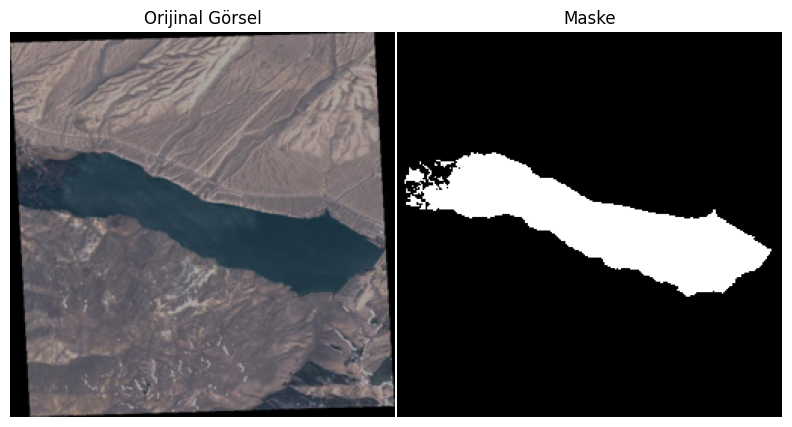

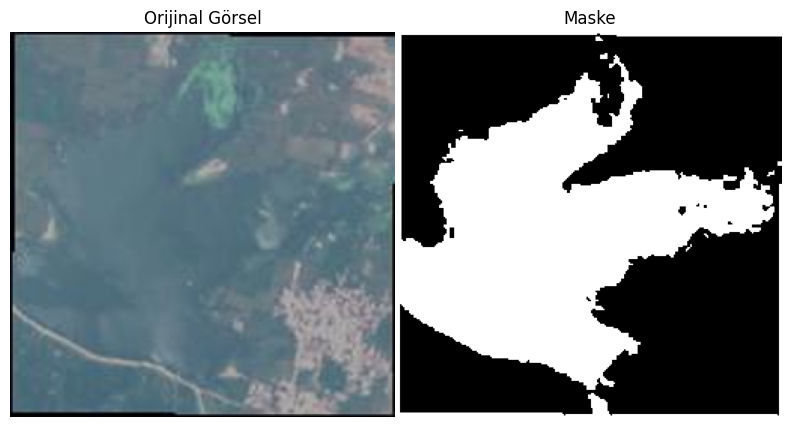

In [ ]:
import random
import matplotlib.pyplot as plt

for i in range(2):
    index = random.randint(0, len(X_val) - 1)
    image = X_val[index]
    true_mask = Y_val[index]

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    axs[0].imshow(image)
    axs[0].set_title("Orijinal Görsel")
    axs[0].axis("off")

    axs[1].imshow(true_mask.squeeze(), cmap='gray')
    axs[1].set_title("Maske")
    axs[1].axis("off")

    plt.subplots_adjust(wspace=0)
    plt.show()

### Modelin Oluşturulması ve Hiperparametrelerin Ayarlanması

In [ ]:
# Kayıp ve metrik fonksiyonları
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred = K.cast(y_pred > 0.5, 'float32')
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def precision_metric(y_true, y_pred):
    y_pred = K.cast(y_pred > 0.5, 'float32')
    tp = K.sum(y_true * y_pred)
    predicted = K.sum(y_pred)
    return tp / (predicted + 1e-6)

def recall_metric(y_true, y_pred):
    y_pred = K.cast(y_pred > 0.5, 'float32')
    tp = K.sum(y_true * y_pred)
    actual = K.sum(y_true)
    return tp / (actual + 1e-6)

**Model**

In [ ]:
def unet_advanced(input_size=(256, 256, 3)):
    inputs = layers.Input(input_size)

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        return x

    def encoder_block(x, filters):
        c = conv_block(x, filters)
        p = layers.MaxPooling2D()(c)
        return c, p

    def decoder_block(x, skip, filters):
        x = layers.UpSampling2D()(x)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, filters)
        return x

    c1, p1 = encoder_block(inputs, 64)
    c2, p2 = encoder_block(p1, 128)
    c3, p3 = encoder_block(p2, 256)
    c4, p4 = encoder_block(p3, 512)

    bn = conv_block(p4, 1024)
    bn = layers.Dropout(0.3)(bn)

    d1 = decoder_block(bn, c4, 512)
    d2 = decoder_block(d1, c3, 256)
    d3 = decoder_block(d2, c2, 128)
    d4 = decoder_block(d3, c1, 64)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d4)
    return models.Model(inputs, outputs)

model = unet_advanced()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,402,497 (119.79 MB)

 Trainable params: 31,390,721 (119.75 MB)

 Non-trainable params: 11,776 (46.00 KB)

### Modelin Derlenmesi ve Eğitilmesi

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[iou_metric, dice_coef, precision_metric, recall_metric]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/best_water_model.keras", monitor='val_dice_coef', mode='max', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_dice_coef', mode='max', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

In [ ]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=15,
    batch_size=8,
    callbacks=callbacks
)

Epoch 1/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 232s 601ms/step - dice_coef: 0.6167 - iou_metric: 0.5369 - loss: 0.8490 - precision_metric: 0.7003 - recall_metric: 0.6926 - val_dice_coef: 0.4842 - val_iou_metric: 0.3279 - val_loss: 3.6760 - val_precision_metric: 0.3326 - val_recall_metric: 0.9648 - learning_rate: 1.0000e-04
Epoch 2/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 156s 549ms/step - dice_coef: 0.6855 - iou_metric: 0.6089 - loss: 0.7064 - precision_metric: 0.7692 - recall_metric: 0.7534 - val_dice_coef: 0.6572 - val_iou_metric: 0.5750 - val_loss: 0.8140 - val_precision_metric: 0.6311 - val_recall_metric: 0.8661 - learning_rate: 1.0000e-04
Epoch 3/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 155s 546ms/step - dice_coef: 0.7187 - iou_metric: 0.6454 - loss: 0.6520 - precision_metric: 0.7920 - recall_metric: 0.7846 - val_dice_coef: 0.7445 - val_iou_metric: 0.6712 - val_loss: 0.5658 - val_precision_metric: 0.8348 - val_recall_metric: 0.7720 - learning_rate: 1.0000e-04
Epoch 4/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 156s 5

### Sonuçların Görselleştirilmesi

In [ ]:
def plot_training_history(history):
    metrics = ['loss', 'dice_coef', 'iou_metric', 'precision_metric', 'recall_metric']
    titles = {
        'loss': 'Kayıp (Loss)',
        'dice_coef': 'Dice Katsayısı',
        'iou_metric': 'IoU (Intersection over Union)',
        'precision_metric': 'Precision (Kesinlik)',
        'recall_metric': 'Recall (Duyarlılık)'
    }

    for metric in metrics:
        plt.figure(figsize=(8, 5))
        plt.plot(history.history[metric], label='Eğitim')
        plt.plot(history.history[f'val_{metric}'], label='Doğrulama')
        plt.title(titles.get(metric, metric))
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

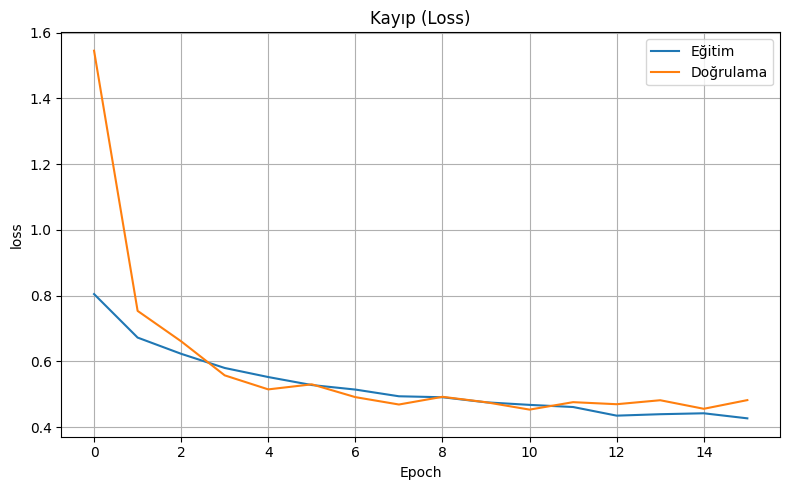

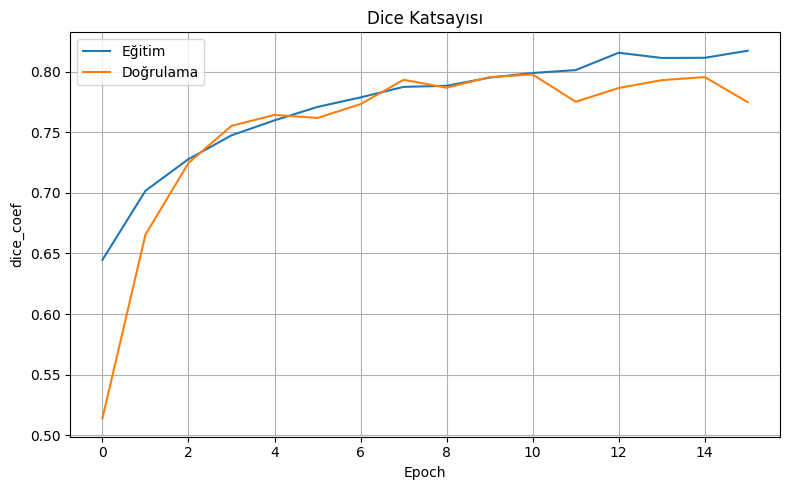

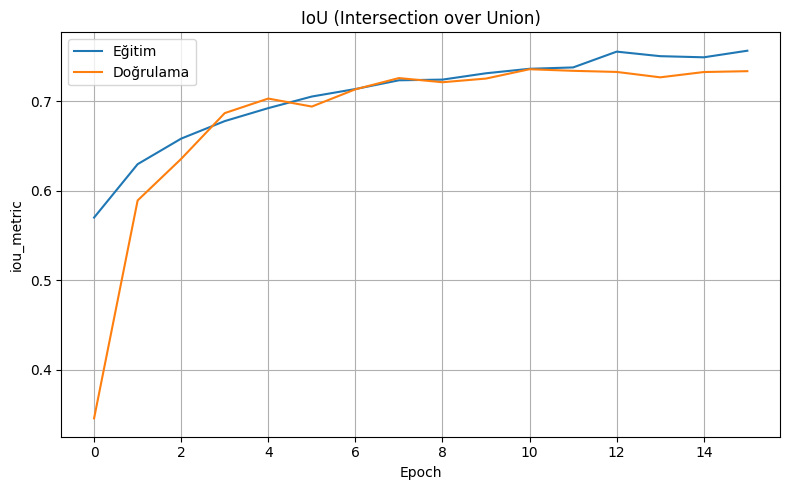

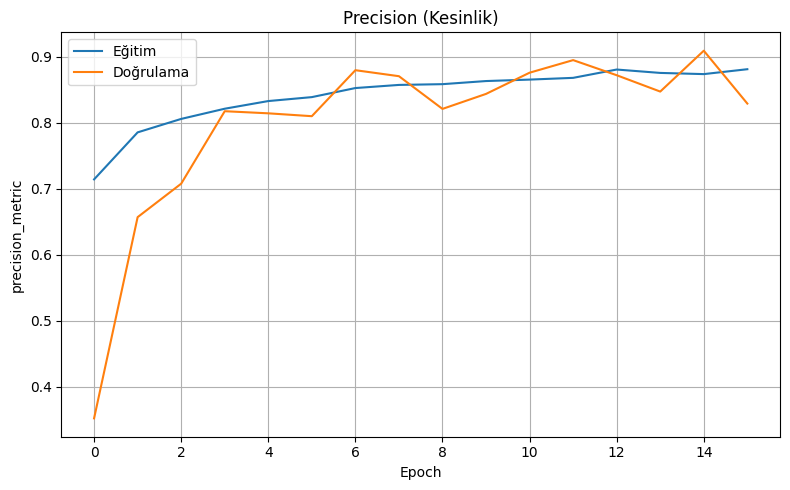

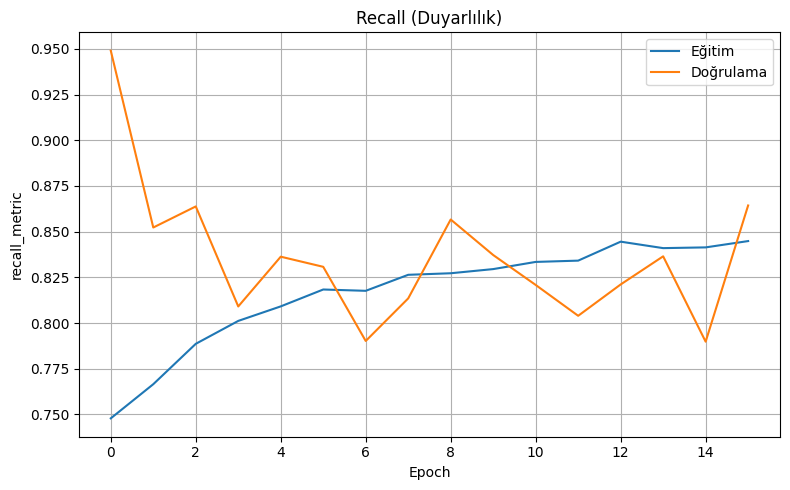

In [ ]:
plot_training_history(history)

### Modelin Kaydedilmesi

In [ ]:
model.save('/content/drive/MyDrive/water_segmentation_model2.keras')

### Modelin Test Edilmesi

In [ ]:
from PIL import Image
import numpy as np

def preprocess_image(image_path, target_size=(256, 256)):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(target_size)
    img = np.asarray(img, dtype=np.float32) / 255.0
    return np.expand_dims(img, axis=0)

def predict_mask(image_path):
    img = preprocess_image(image_path)
    pred = model.predict(img)[0, :, :, 0]
    mask = (pred > 0.5).astype(np.uint8)
    return mask

In [ ]:
import matplotlib.pyplot as plt

def test_and_visualize(image_path):
    mask = predict_mask(image_path)
    area = np.sum(mask)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(image_path).resize((256, 256)))
    plt.title("Orijinal Görsel")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="Blues")
    plt.title(f"Segmentasyon Maskesi\nSu Alanı: {area} piksel")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return area

In [ ]:
image_path="Lake_2014.png"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


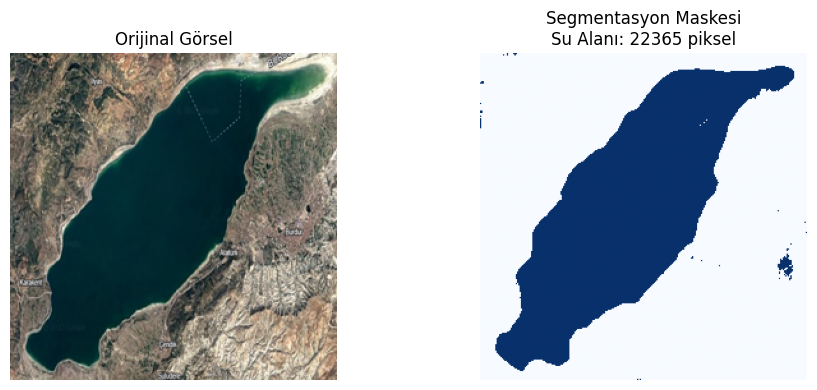

np.uint64(22365)

In [ ]:
test_and_visualize(image_path)